In [ ]:




# dummy_l8 = torch.randn(1, 11, 224, 224)
# dummy_s2 = torch.randn(1, 13, 224, 224)

# l8_encoder = EncoderL8(in_channels=11)
# s2_encoder = S2Encoder(in_channels=13)

# z_l8 = l8_encoder(dummy_l8)
# z_s2 = s2_encoder(dummy_s2)

# print(z_l8.shape, z_s2.shape)

In [1]:
# import re
# from pathlib import Path
# import numpy as np
# import rasterio
# from rasterio.enums import Resampling

# def read_safe_l1c(path, stack=True, resample=False, bands=None):
#     path = Path(path)
#     default_bands = ["B01","B02","B03","B04","B05","B06","B07",
#                      "B08","B8A","B09","B10","B11","B12"]

#     if bands is None:
#         patterns = default_bands
#     else:
#         patterns = [f"B{str(b).zfill(2)}" if isinstance(b,int) else str(b).upper() for b in bands]

#     regexes = [re.compile(p, flags=re.IGNORECASE) for p in patterns]

#     img_dirs = [d for d in path.rglob("*") if d.is_dir() and "IMG_DATA" in d.name]
#     if not img_dirs:
#         raise ValueError(f"No IMG_DATA found in {path}")
#     img_dir = img_dirs[0]

#     files = [p for p in img_dir.glob("*.jp2") if p.is_file() and "TCI" not in p.name.upper()]
#     valid_files = [f for f in files if any(r.search(f.name) for r in regexes)]
#     if not valid_files:
#         raise ValueError(f"No matching bands found for {patterns}")

#     arrays = {}
#     meta = None

#     ref_file = next((f for f in valid_files if "B04" in f.name.upper()), None)
#     if ref_file is None:
#         raise ValueError("Reference band B04 not found for resampling.")

#     with rasterio.open(ref_file) as ref_src:
#         ref_shape = (ref_src.height, ref_src.width)
#         ref_transform = ref_src.transform
#         ref_profile = ref_src.profile.copy()
#         ref_meta = ref_src.meta.copy()
#         arrays["B04"] = ref_src.read(1)
#         if meta is None:
#             meta = ref_src.meta.copy()

#     for f in valid_files:
#         fname = f.name.upper()
#         if "B04" in fname:
#             continue
#         if "B8A" in fname:
#             band_id = "B8A"
#         else:
#             m = re.search(r"B(\d+)", fname)
#             if not m:
#                 continue
#             band_id = f"B{m.group(1).zfill(2)}"

#         with rasterio.open(f) as src:
#             if resample:
#                 arr = src.read(
#                     1,
#                     out_shape=(ref_shape[0], ref_shape[1]),
#                     resampling=Resampling.cubic
#                 )
#             else:
#                 arr = src.read(1)
#             arrays[band_id] = arr

#     band_order = patterns if bands is not None else default_bands
#     missing = [b for b in band_order if b not in arrays]
#     if missing:
#         raise ValueError(f"Missing bands: {missing}")

#     data = np.stack([arrays[b] for b in band_order], axis=0) if stack else {b: arrays[b] for b in band_order}

#     meta.update(ref_profile)

#     return data, meta, ref_meta


# def read_safe_l8(path, s2_meta, stack=True, resample=True, bands=None):
#     from rasterio.warp import reproject, Resampling

#     path = Path(path)
#     default_bands = ["B1","B2","B3","B4","B5","B6","B7","B8","B9","B10","B11"]

#     if bands is None:
#         patterns = default_bands
#     else:
#         patterns = [f"B{str(b)}" if isinstance(b,int) else str(b).upper() for b in bands]

#     regexes = [re.compile(f"_{p}\\.TIF$", flags=re.IGNORECASE) for p in patterns]

#     files = [p for p in path.glob("*.TIF") if p.is_file() and 
#              not any(x in p.name.upper() for x in ["QA_", "SAA", "SZA", "VAA", "VZA"])]

#     valid_files = [f for f in files if any(r.search(f.name) for r in regexes)]
#     if not valid_files:
#         raise ValueError(f"No matching bands found for {patterns}")

#     arrays = {}

#     for f in valid_files:
#         fname = f.name.upper()
#         m = re.search(r"_B(\d+)\.TIF$", fname)
#         if not m:
#             continue
#         band_id = f"B{m.group(1)}"

#         with rasterio.open(f) as src:
#             if resample:
#                 arr = np.empty((s2_meta["height"], s2_meta["width"]), dtype=src.meta["dtype"])
#                 reproject(
#                     source=rasterio.band(src, 1),
#                     destination=arr,
#                     src_transform=src.transform,
#                     src_crs=src.crs,
#                     dst_transform=s2_meta["transform"],
#                     dst_crs=s2_meta["crs"],
#                     resampling=Resampling.cubic
#                 )
#             else:
#                 arr = src.read(1)
#             arrays[band_id] = arr

#     band_order = patterns if bands is not None else default_bands
#     missing = [b for b in band_order if b not in arrays]
#     if missing:
#         raise ValueError(f"Missing bands: {missing}")

#     data = np.stack([arrays[b] for b in band_order], axis=0) if stack else {b: arrays[b] for b in band_order}

#     meta = s2_meta.copy()
#     meta.update({
#         "count": len(band_order),
#         "dtype": data.dtype
#     })

#     return data, meta




import numpy as np
import rasterio
from pathlib import Path

def read_stacked_tif(path, stack=True, bands=None):
    path = Path(path)
    with rasterio.open(path) as src:
        count = src.count
        band_indices = list(range(1, min(count,7)+1)) if bands is None else bands
        arrays = {f"B{str(i).zfill(2)}": src.read(i) for i in band_indices}
        band_order = [f"B{str(i).zfill(2)}" for i in band_indices]
        data = np.stack([arrays[b] for b in band_order], axis=0) if stack else {b: arrays[b] for b in band_order}
        meta = src.meta.copy()
        meta.update({"count": len(band_order)})
    return data, meta


In [2]:
data, meta = read_stacked_tif("/mnt/raid1/mosaic/data/o/S2L/51QUV/stacked/S2B_MSIL2F_20240501T021529_N0405_R003_T51QUV_20250808T034429.TIF")
data_2,meta_2 = read_stacked_tif("/mnt/raid1/mosaic/data/o/S2L/51QUV/stacked/LS9_OLIL2F_20240501T021614_N0405_R116_T51QUV_20250808T110248.TIF")


In [3]:
data.shape, data_2.shape

((7, 10980, 10980), (7, 10980, 10980))

In [4]:
import numpy as np

def patchify(data1, data2, patch_size=224, num_patches=50):
    _, h, w = data1.shape
    patches1, patches2 = [], []

    for _ in range(num_patches):
        top = np.random.randint(0, h - patch_size)
        left = np.random.randint(0, w - patch_size)
        patches1.append(data1[:, top:top+patch_size, left:left+patch_size])
        patches2.append(data2[:, top:top+patch_size, left:left+patch_size])

    return np.stack(patches1), np.stack(patches2)


In [5]:
s2_patches, l8_patches = patchify(data, data_2, patch_size=224, num_patches=10)

In [6]:
s2_patches.shape, l8_patches.shape

((10, 7, 224, 224), (10, 7, 224, 224))

In [ ]:
import torch
import torch.nn.functional as F
import torch
from l8_9_sncoder import EncoderL8
from s2_encoder import S2Encoder

# l1c_tensor: [num_patches, 13, H, W]
# l8_tensor:  [num_patches, 11, H, W]


l8_encoder = EncoderL8(in_channels=7)
s2_encoder = S2Encoder(in_channels=7)
l1c_tensor = torch.tensor(s2_patches, dtype=torch.float32)
l8_tensor = torch.tensor(l8_patches, dtype=torch.float32)

with torch.no_grad():
    z_l8 = l8_encoder(l8_tensor)   # [num_patches, embedding_dim]
    z_s2 = s2_encoder(l1c_tensor)  # [num_patches, embedding_dim]

# Normalize embeddings
z_l8_norm = F.normalize(z_l8, dim=1)
z_s2_norm = F.normalize(z_s2, dim=1)

# Cosine similarity per patch
cos_sim = (z_l8_norm * z_s2_norm).sum(dim=1)  # [num_patches]

print("Cosine similarity per patch:", cos_sim)
print("Mean cosine similarity:", cos_sim.mean().item())


/mnt/raid1/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/mnt/raid1/SatRing-One-Embedding-to-Bind-Them-all/src/encoders/l8_9_sncoder.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  wavelengths = torch.tensor(self.wavelengths, dtype=torch.float32, device=x.device)
/mnt/raid1/SatRing-One-Embedding-to-Bind-Them-all/src/encoders/s2_encoder.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  wavelengths = torch.tensor(self.wavelengths, dtype=torch.float32, device=x.device)


Cosine similarity per patch: tensor([[1.0000, 0.9995, 0.9995,  ..., 1.0000, 0.9985, 0.9988],
        [0.9980, 0.9956, 0.9947,  ..., 0.9988, 0.9911, 0.9947],
        [1.0000, 0.9997, 0.9997,  ..., 1.0000, 0.9992, 0.9995],
        ...,
        [0.9978, 0.9958, 0.9928,  ..., 0.9990, 0.9932, 0.9956],
        [0.9999, 0.9991, 0.9995,  ..., 1.0000, 0.9984, 0.9988],
        [0.9804, 0.9667, 0.9666,  ..., 0.9924, 0.9462, 0.9555]])
Mean cosine similarity: 0.9594957232475281


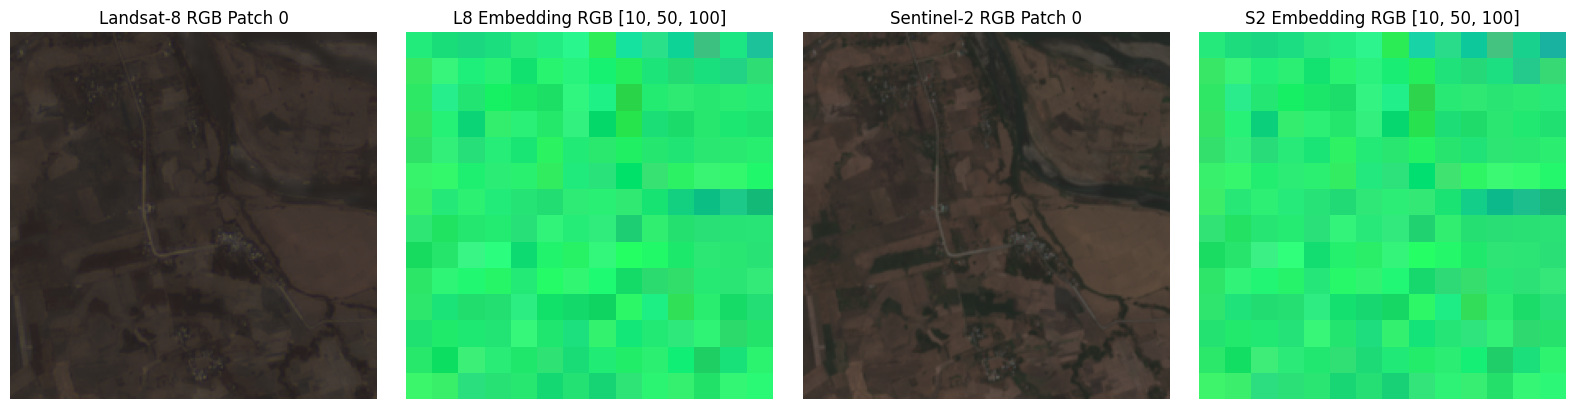

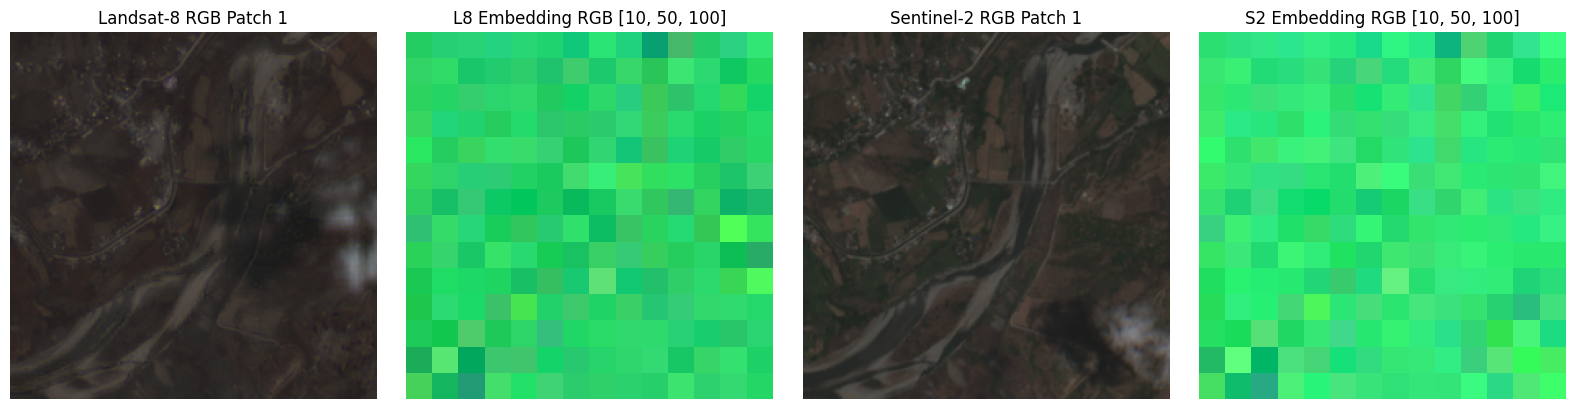

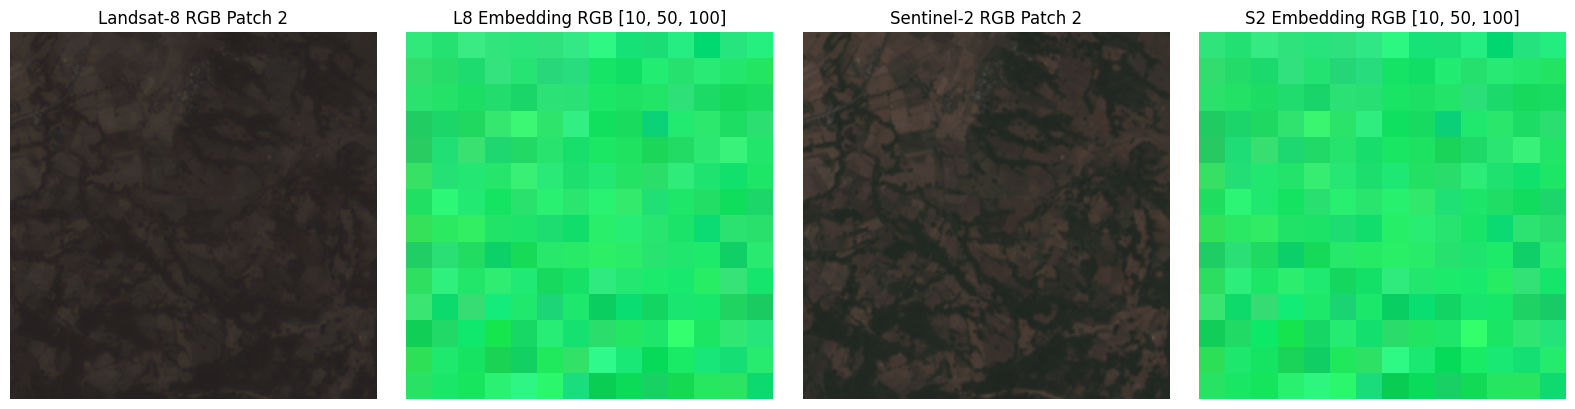

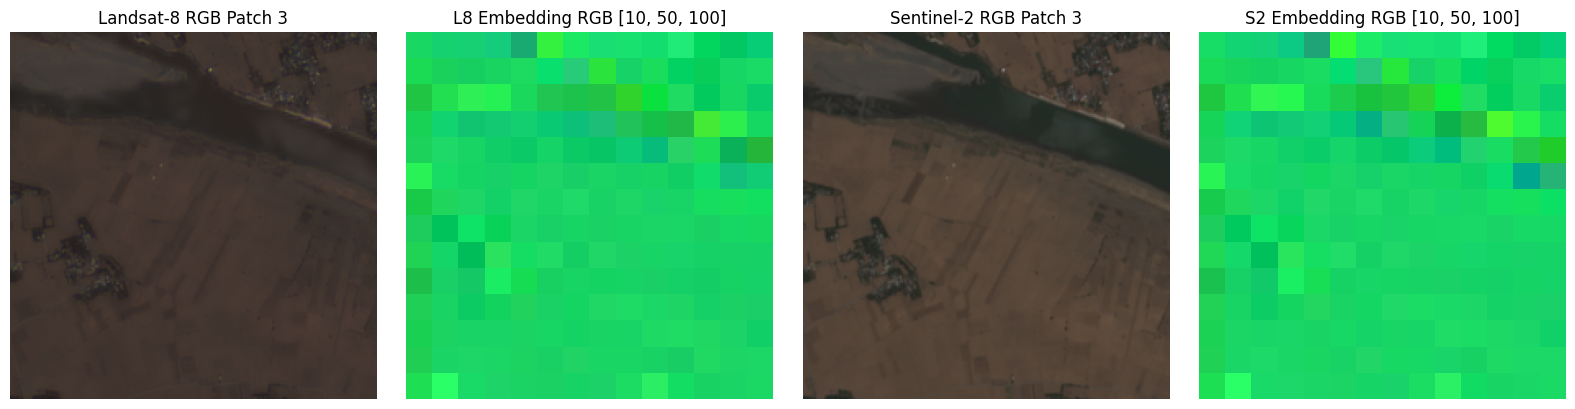

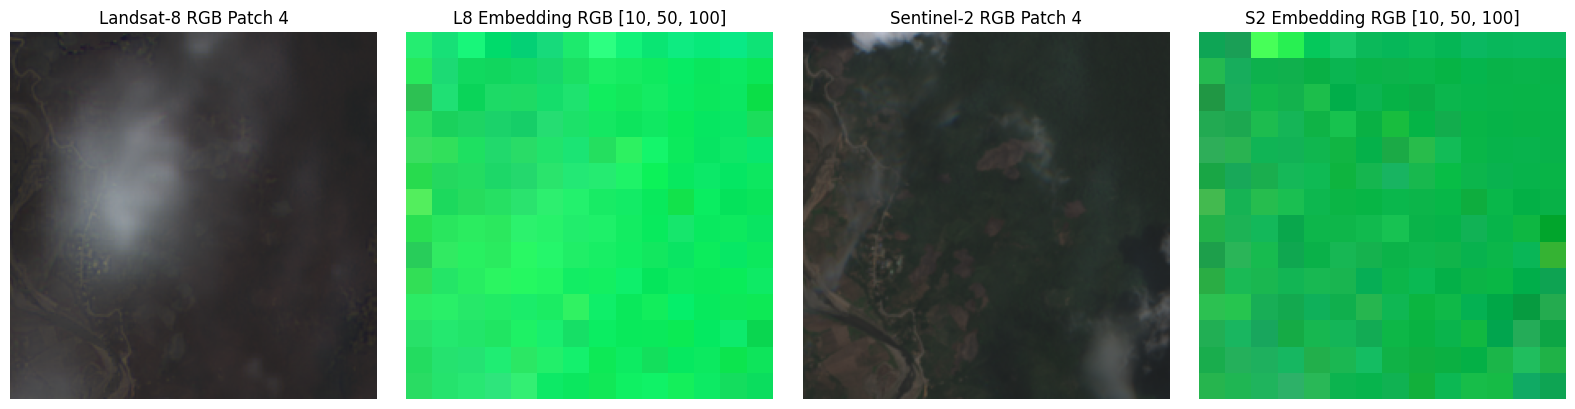

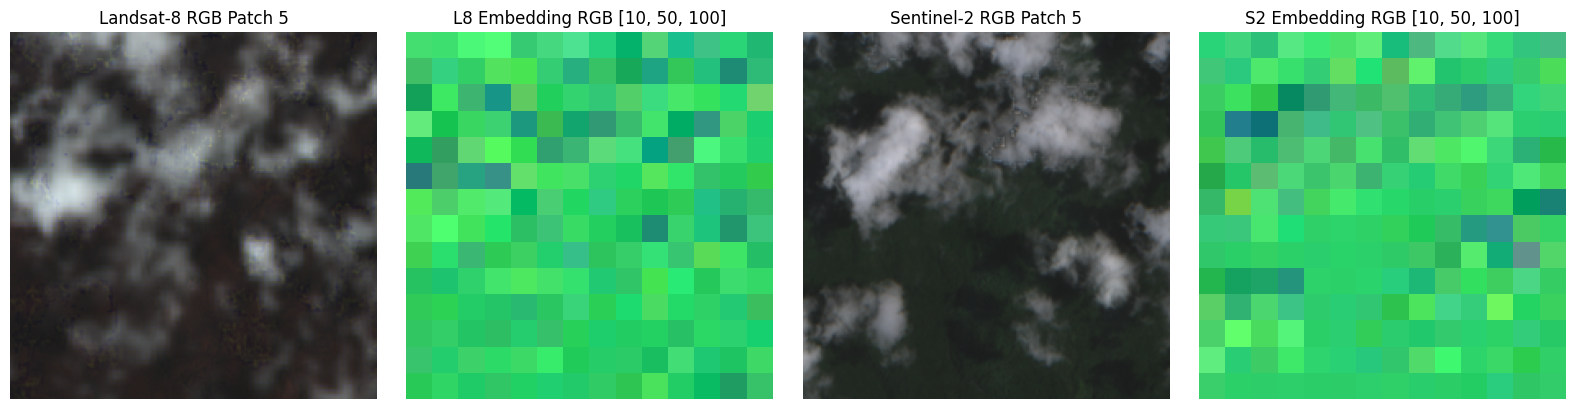

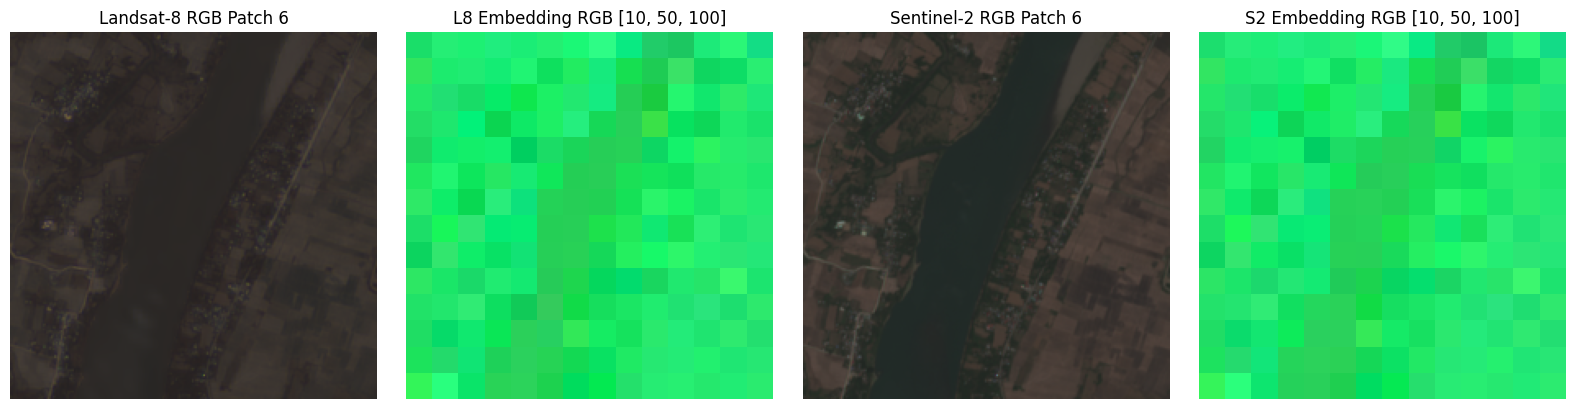

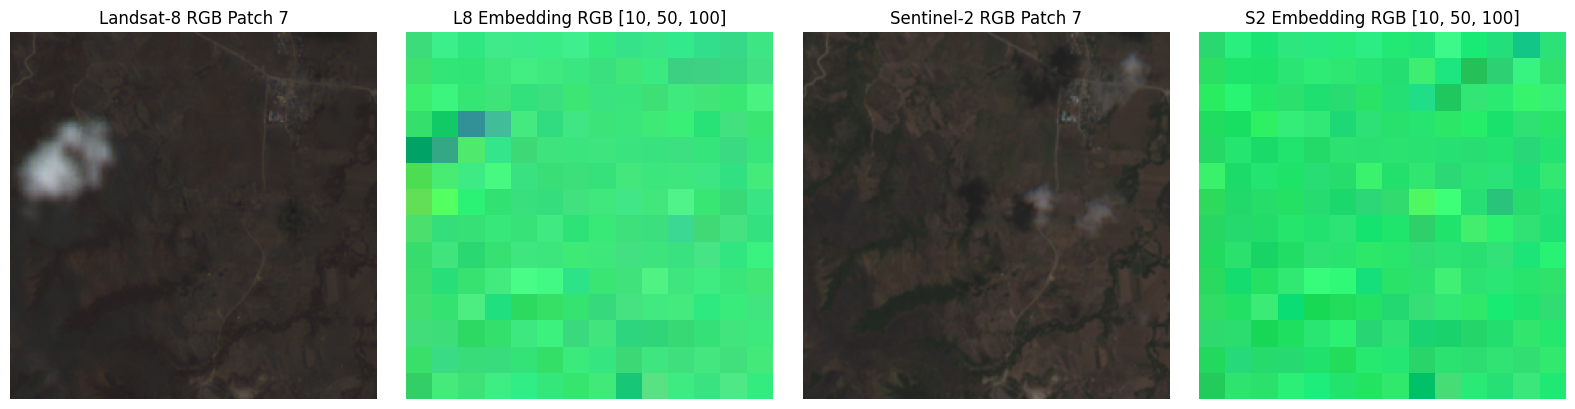

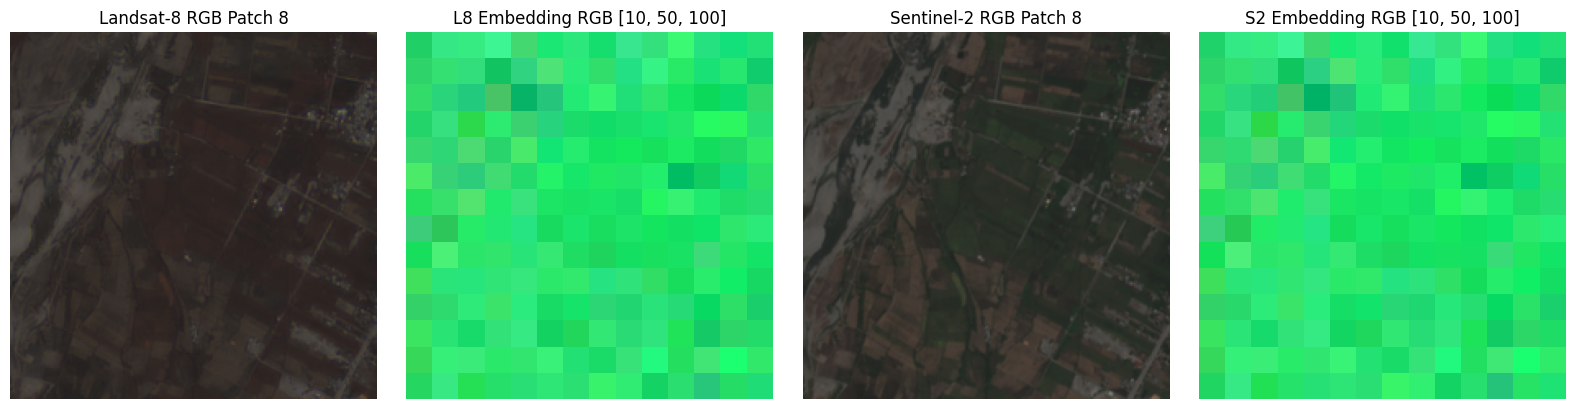

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


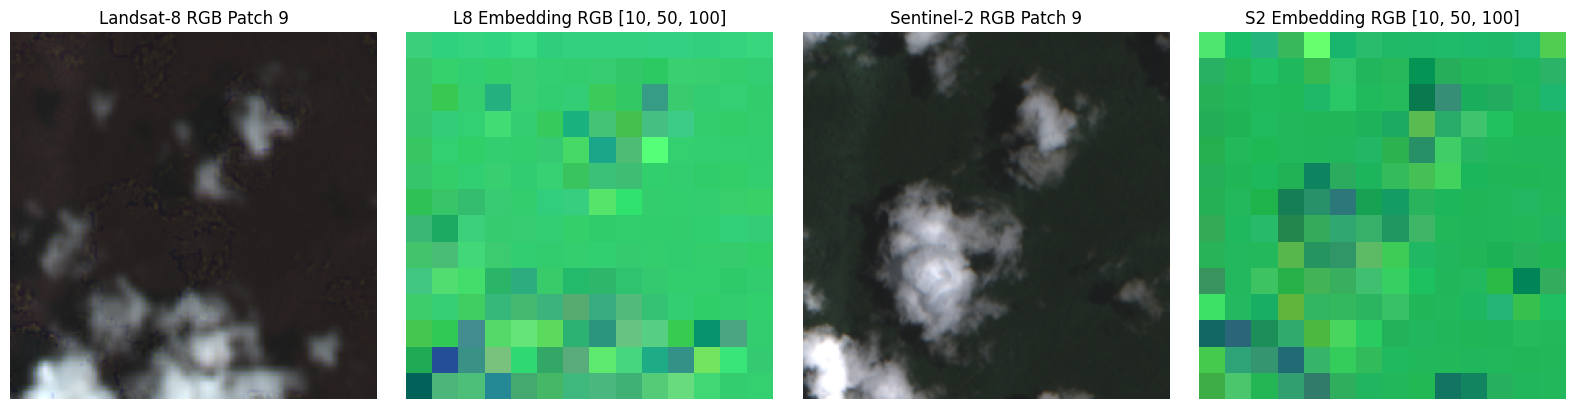

Embedding dimension: 1024


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

def visualize_all_patches_and_embeddings(l8_patches, s2_patches, z_l8, z_s2, rgb_indices=[0,1,2]):
    num_images = l8_patches.shape[0]
    _, _, H, W = l8_patches.shape  # assume both have same patch resolution
    
    for img_idx in range(num_images):
        l8_tokens = z_l8[img_idx, 1:, :].cpu()
        s2_tokens = z_s2[img_idx, 1:, :].cpu()
        num_patches, embed_dim = l8_tokens.shape
        grid_size = int(np.sqrt(num_patches))

        # create pseudo-RGB from embeddings
        l8_rgb_embed = np.stack([
            l8_tokens[:, i].reshape(grid_size, grid_size).numpy()
            for i in rgb_indices
        ], axis=0)
        s2_rgb_embed = np.stack([
            s2_tokens[:, i].reshape(grid_size, grid_size).numpy()
            for i in rgb_indices
        ], axis=0)

        # normalize each embedding for visualization
        l8_rgb_embed = (l8_rgb_embed - l8_rgb_embed.min()) / (l8_rgb_embed.max() - l8_rgb_embed.min())
        s2_rgb_embed = (s2_rgb_embed - s2_rgb_embed.min()) / (s2_rgb_embed.max() - s2_rgb_embed.min())

        # upsample to original resolution using bicubic interpolation
        l8_rgb_embed_up = F.interpolate(
            torch.tensor(l8_rgb_embed).unsqueeze(0),
            size=(H, W),
            mode='bilinear',
            align_corners=False
        ).squeeze(0).permute(1,2,0).numpy()

        s2_rgb_embed_up = F.interpolate(
            torch.tensor(s2_rgb_embed).unsqueeze(0),
            size=(H, W),
            mode='bilinear',
            align_corners=False
        ).squeeze(0).permute(1,2,0).numpy()

        # normalize again to [0,1]
        l8_rgb_embed_up = (l8_rgb_embed_up - l8_rgb_embed_up.min()) / (l8_rgb_embed_up.max() - l8_rgb_embed_up.min())
        s2_rgb_embed_up = (s2_rgb_embed_up - s2_rgb_embed_up.min()) / (s2_rgb_embed_up.max() - s2_rgb_embed_up.min())

        # RGB patches
        rgb_l8_patch = l8_patches[img_idx][[2,1,0]].permute(1,2,0).numpy() / 10000.0
        rgb_s2_patch = s2_patches[img_idx][[3,2,1]].permute(1,2,0).numpy() / 10000.0

        fig, axes = plt.subplots(1, 4, figsize=(16,4))
        axes[0].imshow(rgb_l8_patch)
        axes[0].set_title(f'Landsat-8 RGB Patch {img_idx}')
        axes[0].axis('off')

        axes[1].imshow(l8_rgb_embed_up)
        axes[1].set_title(f'L8 Embedding (Upsampled) {rgb_indices}')
        axes[1].axis('off')

        axes[2].imshow(rgb_s2_patch)
        axes[2].set_title(f'Sentinel-2 RGB Patch {img_idx}')
        axes[2].axis('off')

        axes[3].imshow(s2_rgb_embed_up)
        axes[3].set_title(f'S2 Embedding (Upsampled) {rgb_indices}')
        axes[3].axis('off')

        plt.tight_layout()
        plt.show()

    print(f"Embedding dimension: {embed_dim}")


visualize_all_patches_and_embeddings(l8_tensor, l1c_tensor, z_l8, z_s2, rgb_indices=[10,50,100])


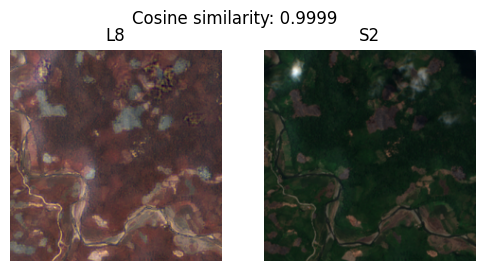

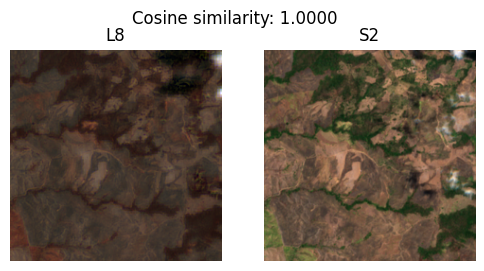

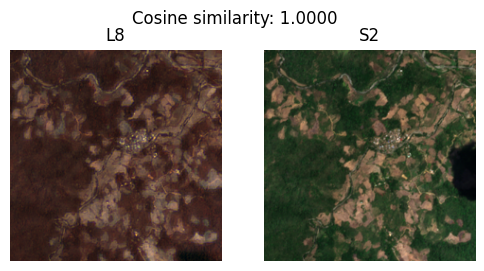

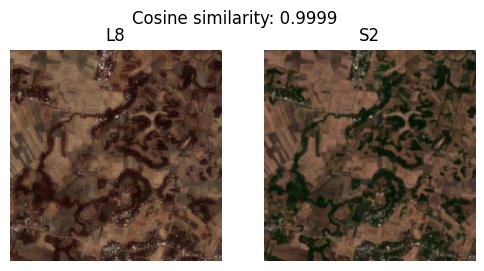

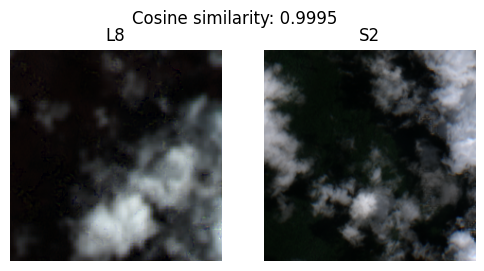

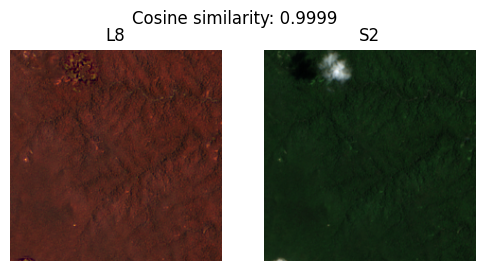

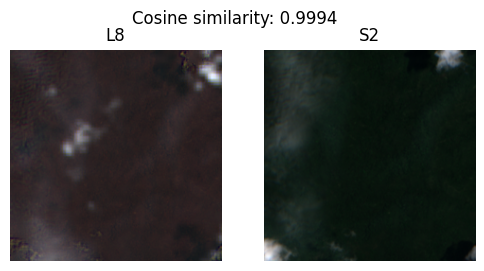

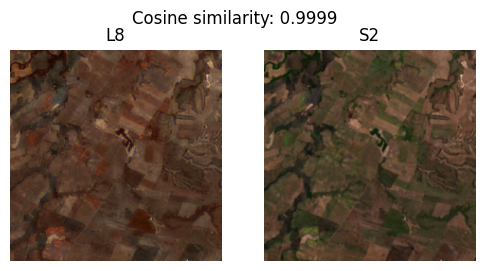

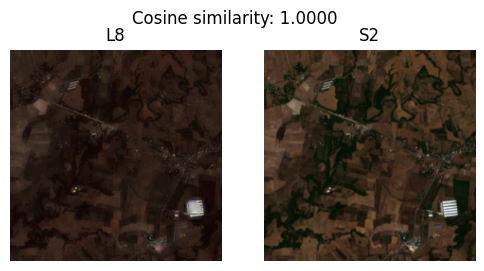

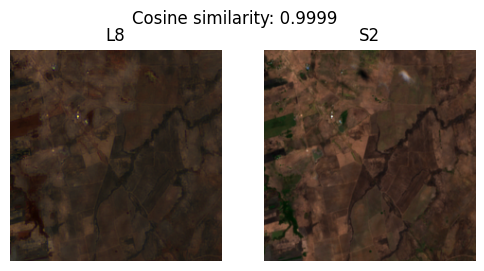

In [23]:
import matplotlib.pyplot as plt

def plot_patches_with_similarity(l8_patches, s2_patches, cos_sim, num_samples=10):
    idxs = torch.arange(len(cos_sim))[:num_samples]
    for i in idxs:
        fig, axes = plt.subplots(1, 2, figsize=(6,3))
        rgb_l8 = l8_patches[i][[2,1,0]].permute(1,2,0).numpy()
        rgb_l8 = (rgb_l8/27500.0) - 0.2
        rgb_l8 = (rgb_l8 - rgb_l8.min())/(rgb_l8.max()-rgb_l8.min())

        rgb_s2 = s2_patches[i][[3,2,1]].permute(1,2,0).numpy()
        rgb_s2 = rgb_s2/10000.0
        rgb_s2 = (rgb_s2 - rgb_s2.min())/(rgb_s2.max()-rgb_s2.min())

        axes[0].imshow(rgb_l8)
        axes[0].set_title("L8")
        axes[0].axis("off")

        axes[1].imshow(rgb_s2)
        axes[1].set_title("S2")
        axes[1].axis("off")

        fig.suptitle(f"Cosine similarity: {cos_sim[i].item():.4f}")
        plt.show()

plot_patches_with_similarity(l8_tensor, l1c_tensor, cos_sim, num_samples=10)


tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0096, 0.0000]],
       grad_fn=<ViewBackward0>)